# Results of evaluation: `geometric`

### These are DRAFT exploratory results

### Legion

Paul Montesano, PhD  
June 2026

In [2]:
library(tidyverse)
library(patchwork)

Warning message:
“package ‘tidyverse’ was built under R version 4.4.3”
Warning message:
“package ‘ggplot2’ was built under R version 4.4.3”
Warning message:
“package ‘tibble’ was built under R version 4.4.3”
Warning message:
“package ‘tidyr’ was built under R version 4.4.3”
Warning message:
“package ‘readr’ was built under R version 4.4.3”
Warning message:
“package ‘purrr’ was built under R version 4.4.3”
Warning message:
“package ‘dplyr’ was built under R version 4.4.3”
Warning message:
“package ‘stringr’ was built under R version 4.4.3”
Warning message:
“package ‘forcats’ was built under R version 4.4.3”
Warning message:
“package ‘lubridate’ was built under R version 4.4.3”
── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.1     ✔ readr     2.2.0
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.2     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.2     
── Conflicts ──────────────────────────────────────

In [3]:
MAINDIR = '/explore/nobackup/projects/CSDA_eval/results/maxar/legion/geometric'

band_colors <- c(
  'Coastal'  = '#4f3a89', 'Blue'     = '#1f78b4',
  'Green'    = '#33a02c', 'Yellow'   = '#ffd92f',
  'Red'      = '#e31a1c', 'RedEdge1' = '#b15928',
  'RedEdge2' = '#8b3a00', 'NIR1'     = 'black' #'#525252'
)

sat_colors <- c(
  'LG01' = '#1b9e77', 'LG02' = '#d95f02', 'LG03' = '#7570b3',
  'LG04' = '#e7298a', 'LG05' = '#66a61e', 'LG06' = '#e6ab02',
  'LG07' = '#a6761d', 'LG08' = '#666666', 'LG09' = '#1f78b4'
)

In [4]:
source('../lib/eval_sites_overview.R')

Warning message:
“package ‘RColorBrewer’ was built under R version 4.4.3”
Warning message:
“package ‘leaflet’ was built under R version 4.4.3”
Warning message:
“package ‘viridis’ was built under R version 4.4.3”
Warning message:
“package ‘viridisLite’ was built under R version 4.4.3”


rnaturalearth unavailable, reading continents from local file...

Warning message in st_cast.sf(., "LINESTRING", do_split = TRUE):
“repeating attributes for all sub-geometries for which they may not be constant”
Warning message:
“No shared levels found between `names(values)` of the manual scale and the
data's fill values.”
Warning message:
“No shared levels found between `names(values)` of the manual scale and the
data's fill values.”


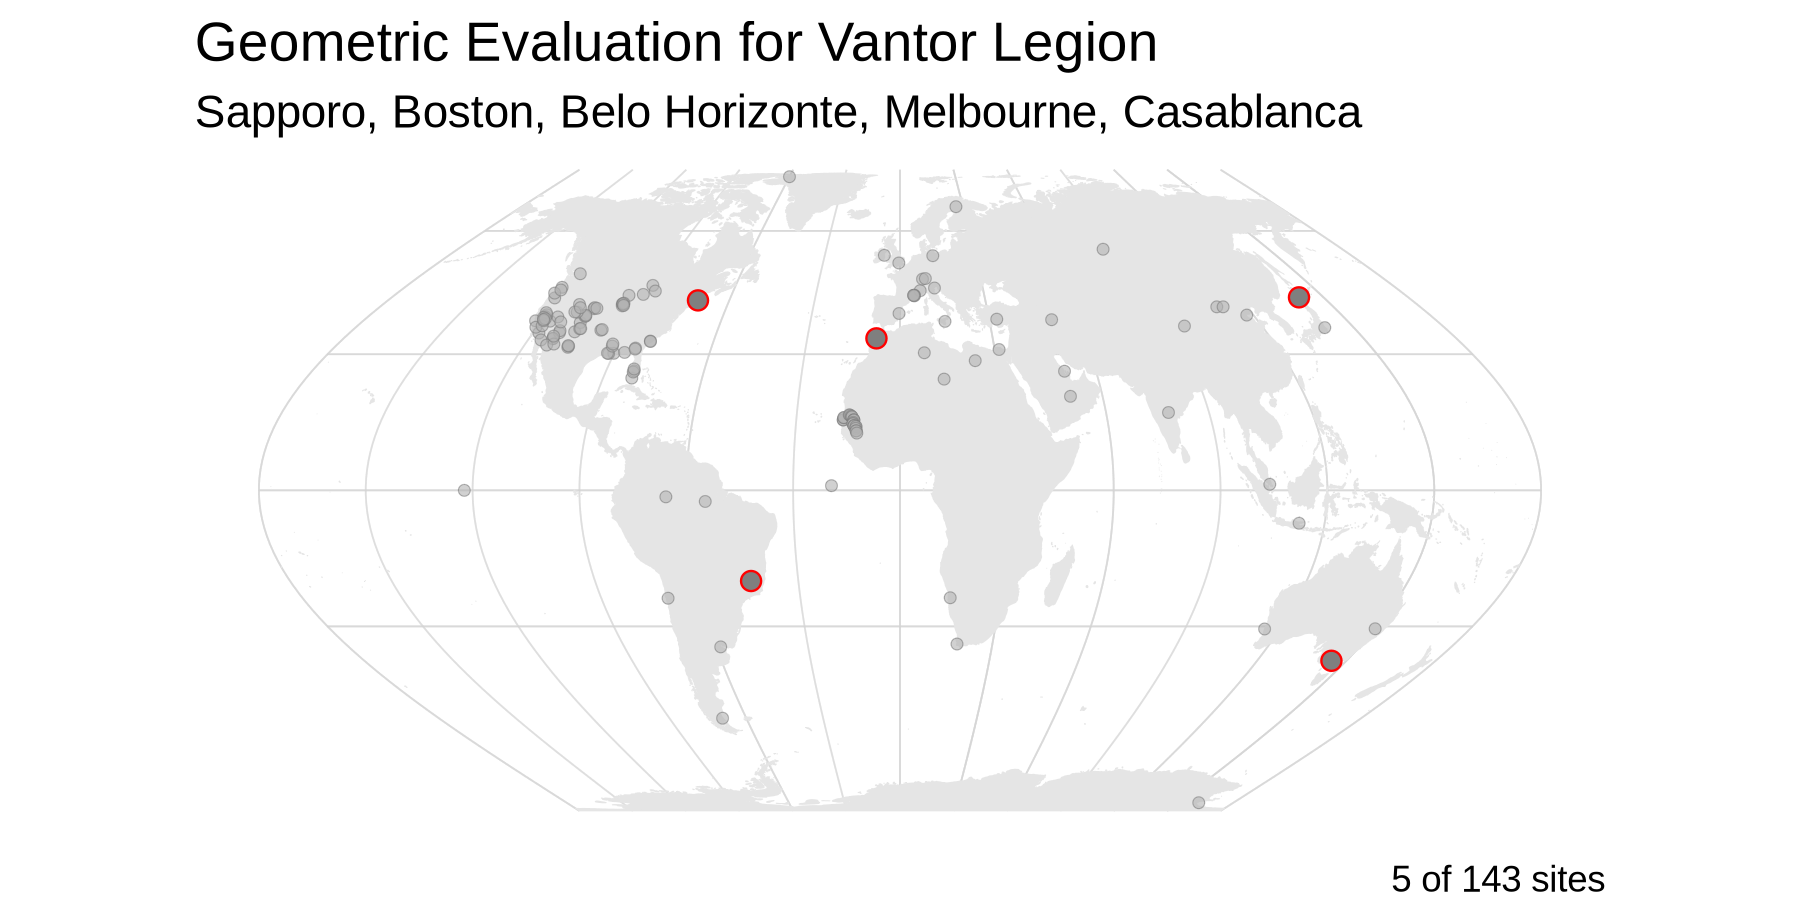

In [5]:
options(repr.plot.width = 6, repr.plot.height = 3, repr.plot.res = 300)

maps <- make_eval_site_overview(
  highlight_sites = c('Sapporo','Boston','Belo Horizonte','Melbourne','Casablanca')
)
maps$map_csda + labs(title = 'Geometric Evaluation for Vantor Legion')

### Table of image IDs

-- probably should be delivered to `CSDA_eval/results/maxar/legion/radiometric`

## APA

In [18]:
fn_apa_list = list.files(paste0(MAINDIR,'/apa/'),  pattern = '\\.csv$', full.names = TRUE)

In [26]:
site_name_crosswalk <- c(
    'japan'     = 'Sapporo',
    'morocco'   = 'Casablanca',
    'melbourne' = 'Melbourne',
    'boston'    = 'Boston',
    'brazil'    = 'Belo Horizonte'
    )

# 2. Read all the apa CSVs
files <- list.files(paste0(MAINDIR, '/apa/'),
                    pattern = '\\.csv$',
                    full.names = TRUE)

df_apa <- files %>%
  setNames(basename(files)) %>%
  lapply(read_csv, show_col_types = FALSE) %>%
  bind_rows(.id = 'source_file')

# 3. Extract the old site name from the filename and map to the new name
df_apa <- df_apa %>%
  mutate(
    # Pull out a "site key" from the filename — adjust regex if needed
    old_site_key = tolower(stringr::str_extract(source_file, '(?i)(japan|morocco|melbourne|boston|brazil)')),
    
    # Map to the standardized Site Name; unmapped → NA
    site_name = unname(site_name_crosswalk[old_site_key])
  )

# 4. Sanity check
df_apa %>% count(source_file, old_site_key, site_name)

source_file,old_site_key,site_name,n
<chr>,<chr>,<chr>,<int>
LEG-bostonnew.csv_filtered.csv,boston,Boston,14
LEG-brazilnew.csv_filtered.csv,brazil,Belo Horizonte,91
LEG-japannew.csv_filtered.csv,japan,Sapporo,30
LEG-melbournenew.csv_filtered.csv,melbourne,Melbourne,50
LEG-morocconew.csv_filtered.csv,morocco,Casablanca,21


In [27]:
head(df_apa)

source_file,file_name,n_chips,xoffset_m,yoffset_m,xstd_m,ystd_m,xrmse_m,yrmse_m,ce90_m,ce90-demean_m,old_site_key,site_name
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
LEG-bostonnew.csv_filtered.csv,/tis/goes_inr/scratch/asemple/legion/boston/results_cpp/WV_20210519154631/25APR09152934-P3DS_R2C1-200012699716_01_P001LEG-_WV02_20210519154631_10300100BE6EE500_21MAY19154631-M1BS-505499660050_01_P006.ntf,61,-0.983076,6.419609,6.316250,8.375364,6.340933,10.498007,19.380732,19.162149,boston,Boston
LEG-bostonnew.csv_filtered.csv,/tis/goes_inr/scratch/asemple/legion/boston/results_cpp/WV_20210519154631/25APR09152934-P3DS_R2C1-200012699716_01_P001LEG-_WV02_20210519154631_10300100BE6EE500_21MAY19154631-P1BS-505499660050_01_P006.ntf,81,-1.048295,6.002761,6.579911,8.036792,6.622662,9.991284,19.580329,20.284509,boston,Boston
LEG-bostonnew.csv_filtered.csv,/tis/goes_inr/scratch/asemple/legion/boston/results_cpp/WV_20210519154631/25APR09152934-P3DS_R3C2-200012699716_01_P001LEG-_WV02_20210519154631_10300100BE6EE500_21MAY19154631-M1BS-505499660050_01_P006.ntf,5,-2.593096,9.466582,0.283545,0.836981,2.605468,9.496136,10.308479,1.145065,boston,Boston
LEG-bostonnew.csv_filtered.csv,/tis/goes_inr/scratch/asemple/legion/boston/results_cpp/WV_20210519154631/25AUG08151820-S3DS_R1C1-200010867957_01_P001LEG-_WV02_20210519154631_10300100BE6EE500_21MAY19154631-M1BS-505499660050_01_P006.ntf,140,-3.913959,8.560612,0.470923,1.010988,3.941987,8.619680,10.196247,1.264787,boston,Boston
LEG-bostonnew.csv_filtered.csv,/tis/goes_inr/scratch/asemple/legion/boston/results_cpp/WV_20210519154631/25AUG08151820-S3DS_R1C1-200010867957_01_P001LEG-_WV02_20210519154631_10300100BE6EE500_21MAY19154631-P1BS-505499660050_01_P006.ntf,137,-3.162661,7.844958,0.389327,1.235650,3.186360,7.940973,9.264598,1.897511,boston,Boston
LEG-bostonnew.csv_filtered.csv,/tis/goes_inr/scratch/asemple/legion/boston/results_cpp/WV_20210519154631/25AUG08151820-S3DS_R1C2-200010867957_01_P001LEG-_WV02_20210519154631_10300100BE6EE500_21MAY19154631-M1BS-505499660050_01_P006.ntf,70,-4.116057,7.543347,4.369593,5.158266,5.980176,9.117548,10.664242,6.566163,boston,Boston


#### Question: is it possible to get acquisition date and satellite id in the CSV output

In [77]:
library(dplyr)
library(ggplot2)
library(tidyr)
library(ggrepel)

# Define a sensible "passing" threshold for CE90 
CE90_THRESHOLD <- 7  # meters — adjust to our spec

# Compute total offset magnitude
df_apa <- df_apa %>%
  mutate(
    total_offset_m = sqrt(xoffset_m^2 + yoffset_m^2),
    total_rmse_m   = sqrt(xrmse_m^2 + yrmse_m^2)
  )

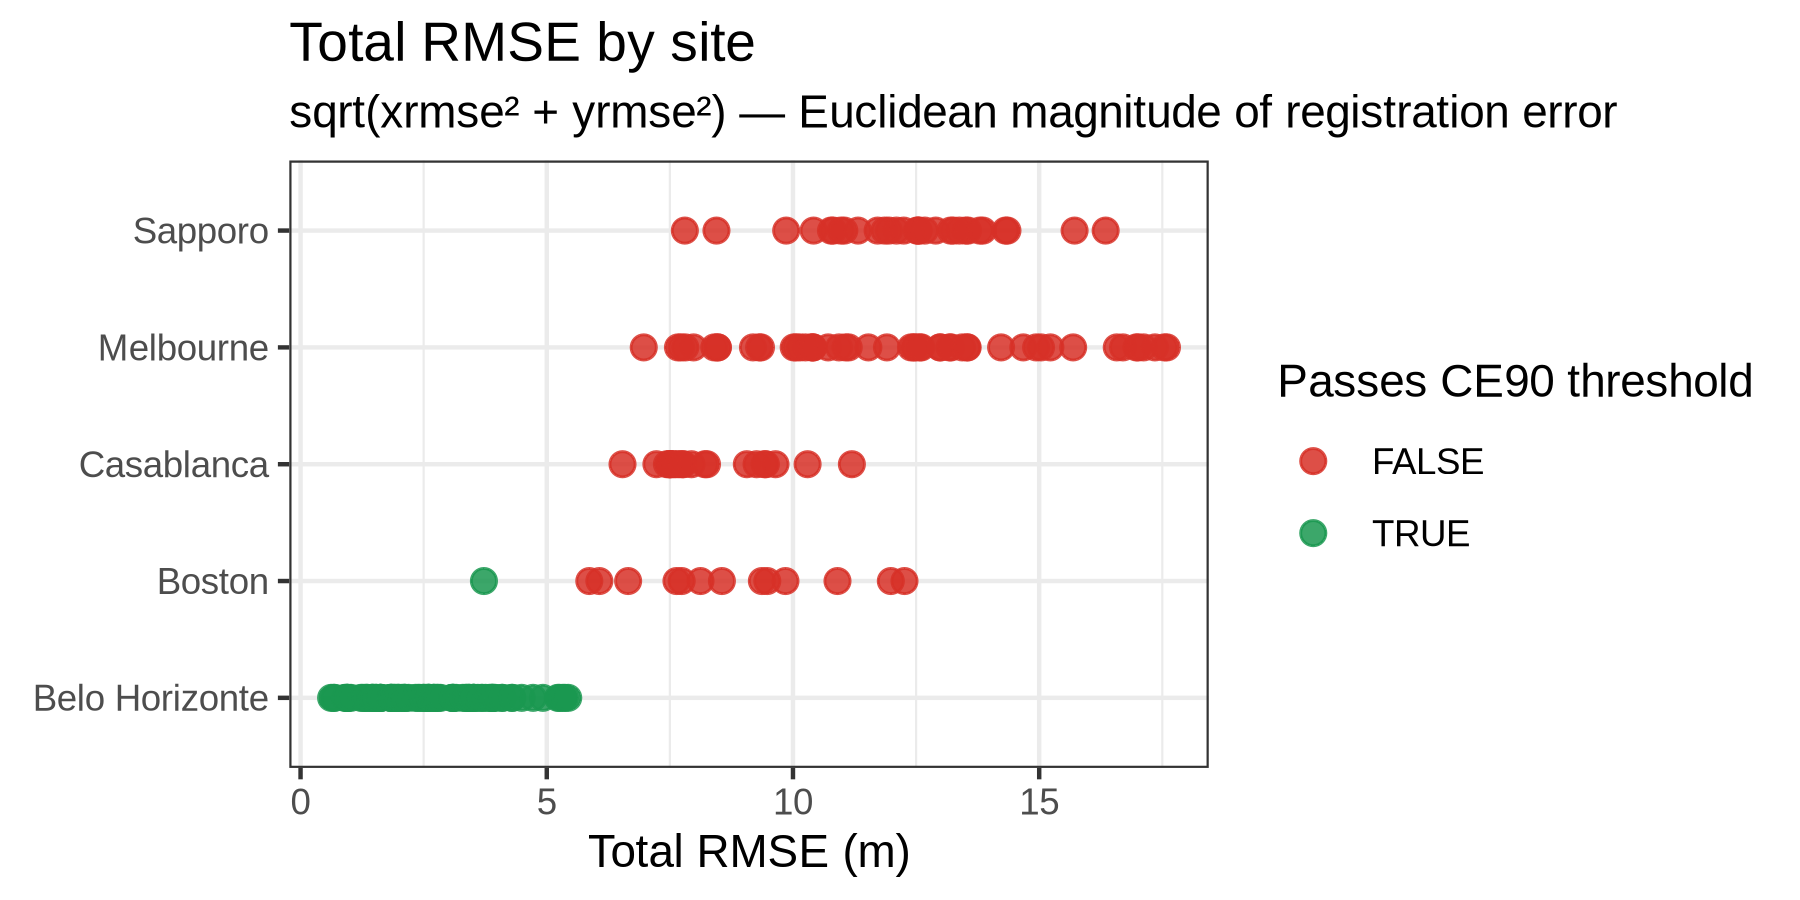

In [79]:
options(repr.plot.width = 6, repr.plot.height = 3, repr.plot.res = 300)

p1b <- df_apa %>%
  arrange(total_rmse_m) %>%
  mutate(site_name = factor(site_name, levels = unique(site_name))) %>%
  ggplot(aes(x = total_rmse_m, y = site_name,
             color = ce90_m <= CE90_THRESHOLD)) +
  geom_point(size = 2.5, alpha = 0.85) +
  scale_color_manual(values = c('TRUE' = '#1a9850', 'FALSE' = '#d73027'),
                     name = 'Passes CE90 threshold') +
  labs(title = 'Total RMSE by site',
       subtitle = 'sqrt(xrmse² + yrmse²) — Euclidean magnitude of registration error',
       x = 'Total RMSE (m)', y = NULL) +
  theme_bw(base_size = 11)

p1b

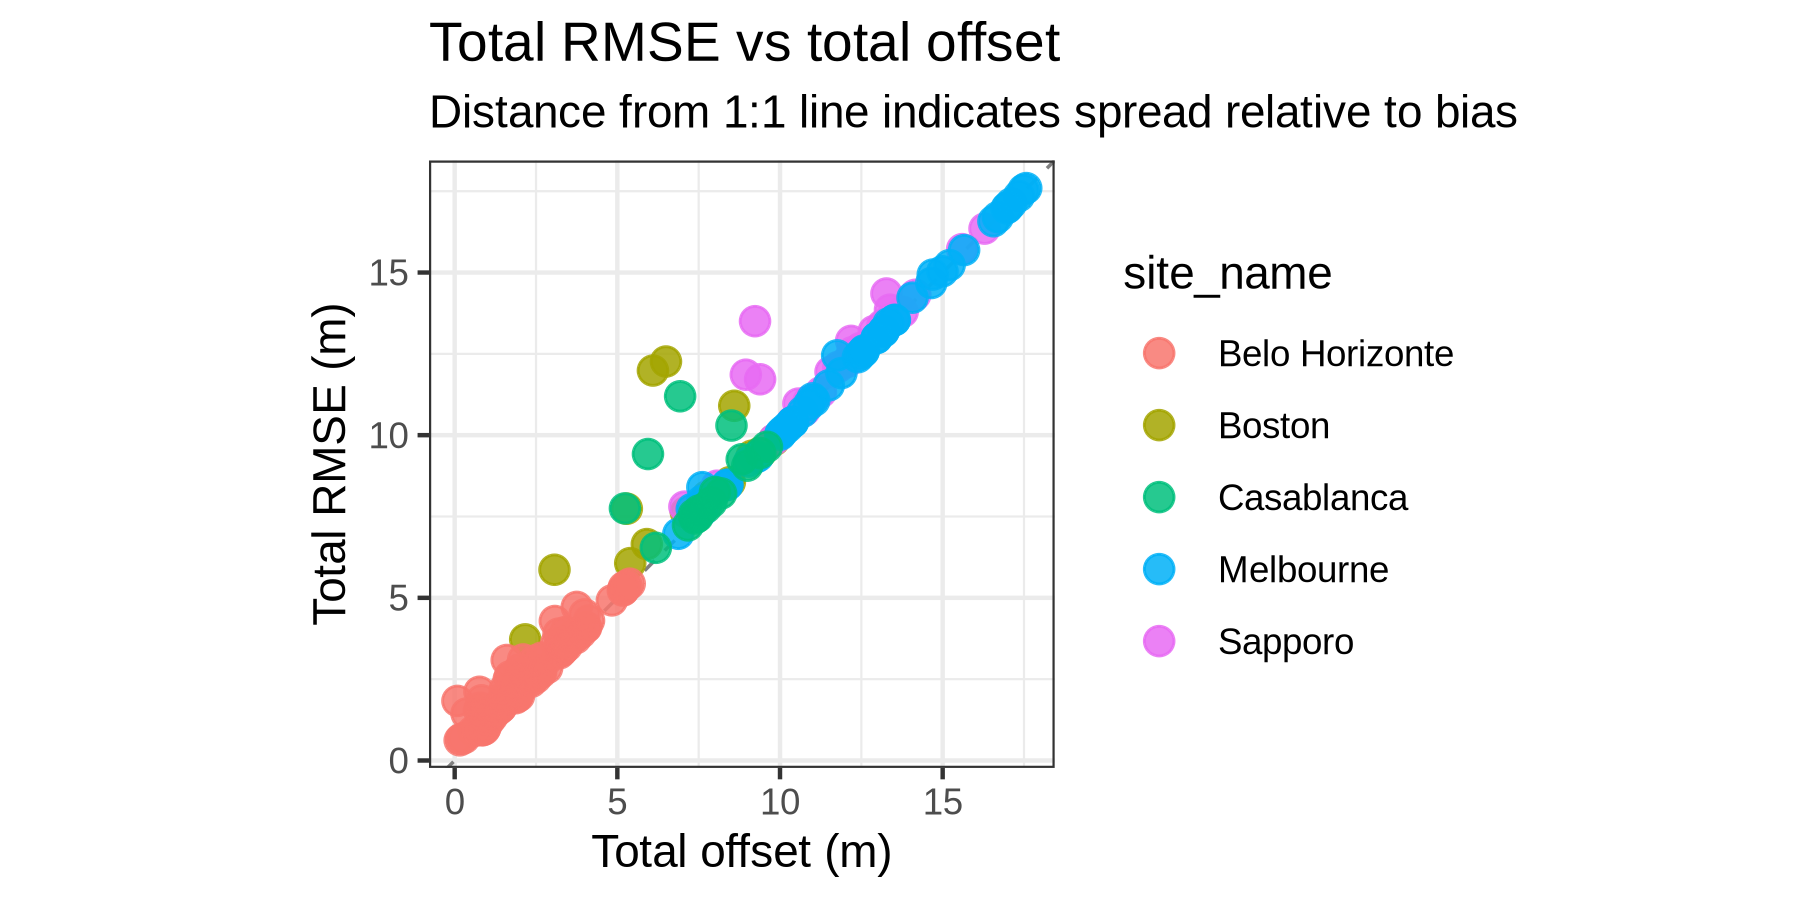

In [81]:
p_rmse_vs_offset <- ggplot(df_apa, aes(x = total_offset_m,
                                        y = total_rmse_m,
                                        color = site_name)) +
  geom_abline(slope = 1, intercept = 0, linetype = 'dashed',
              color = 'grey50', linewidth = 0.4) +
  geom_point(size = 3, alpha = 0.85) +
  labs(title = 'Total RMSE vs total offset',
       subtitle = 'Distance from 1:1 line indicates spread relative to bias',
       x = 'Total offset (m)', y = 'Total RMSE (m)') +
  theme_bw(base_size = 11) +
  coord_equal()

p_rmse_vs_offset

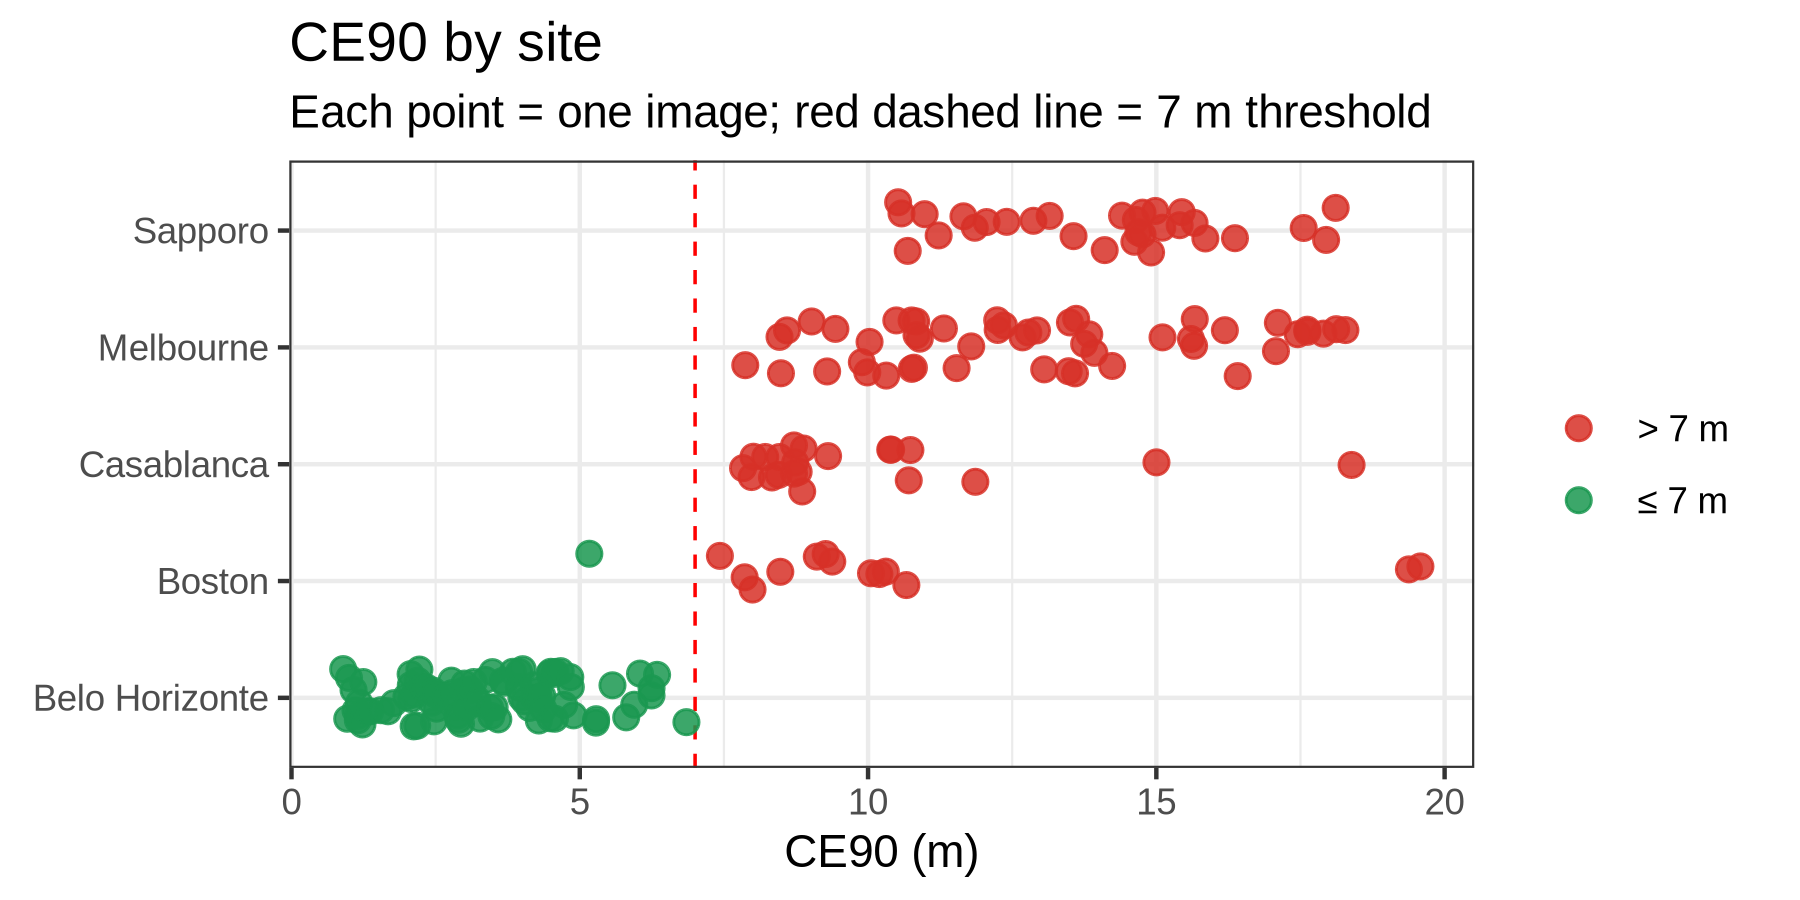

In [46]:
options(repr.plot.width = 6, repr.plot.height = 3, repr.plot.res = 300)

p1 <- df_apa %>%
  arrange(ce90_m) %>%
  mutate(site_name = factor(site_name, levels = unique(site_name))) %>%
  ggplot(aes(x = ce90_m, y = site_name, color = ce90_m <= CE90_THRESHOLD)) +
  geom_vline(xintercept = CE90_THRESHOLD,
             linetype = 'dashed', color = 'red', linewidth = 0.4) +
  geom_jitter(size = 2.5, height = 0.25, alpha = 0.85) +
  scale_color_manual(values = c('TRUE' = '#1a9850', 'FALSE' = '#d73027'),
                     labels = c('TRUE' = paste0('≤ ', CE90_THRESHOLD, ' m'),
                                'FALSE' = paste0('> ', CE90_THRESHOLD, ' m')),
                     name = NULL) +
  labs(title = 'CE90 by site',
       subtitle = sprintf('Each point = one image; red dashed line = %d m threshold',
                          CE90_THRESHOLD),
       x = 'CE90 (m)', y = NULL) +
  theme_bw(base_size = 11)

p1

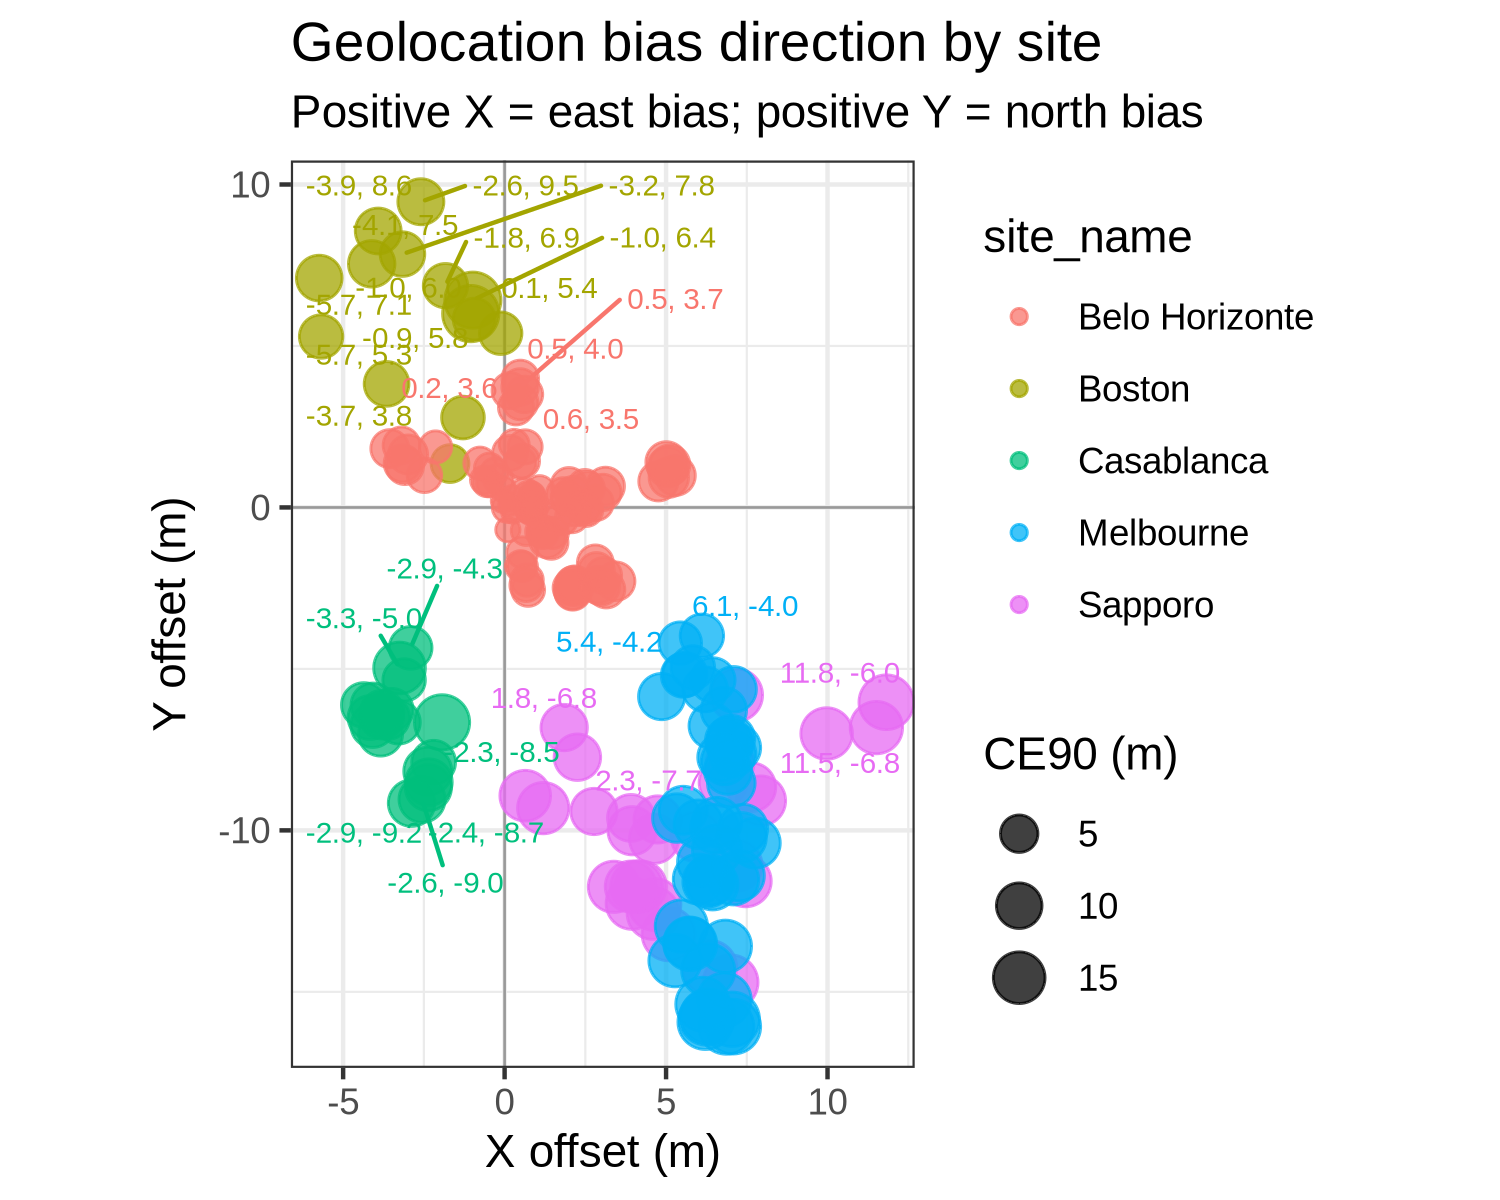

In [47]:
options(repr.plot.width = 5, repr.plot.height = 4, repr.plot.res = 300)

p2 <- ggplot(df_apa, aes(x = xoffset_m, y = yoffset_m,
                          color = site_name, size = ce90_m)) +
  geom_hline(yintercept = 0, color = 'grey60', linewidth = 0.3) +
  geom_vline(xintercept = 0, color = 'grey60', linewidth = 0.3) +
  geom_point(alpha = 0.75) +
  geom_text_repel(aes(label = sprintf('%.1f, %.1f', xoffset_m, yoffset_m)),
                  size = 2.5, max.overlaps = 15, show.legend = FALSE) +
  scale_size_continuous(range = c(2, 6), name = 'CE90 (m)') +
  labs(title = 'Geolocation bias direction by site',
       subtitle = 'Positive X = east bias; positive Y = north bias',
       x = 'X offset (m)', y = 'Y offset (m)') +
  theme_bw(base_size = 11) +
  coord_equal()

p2

`geom_smooth()` using formula = 'y ~ x'


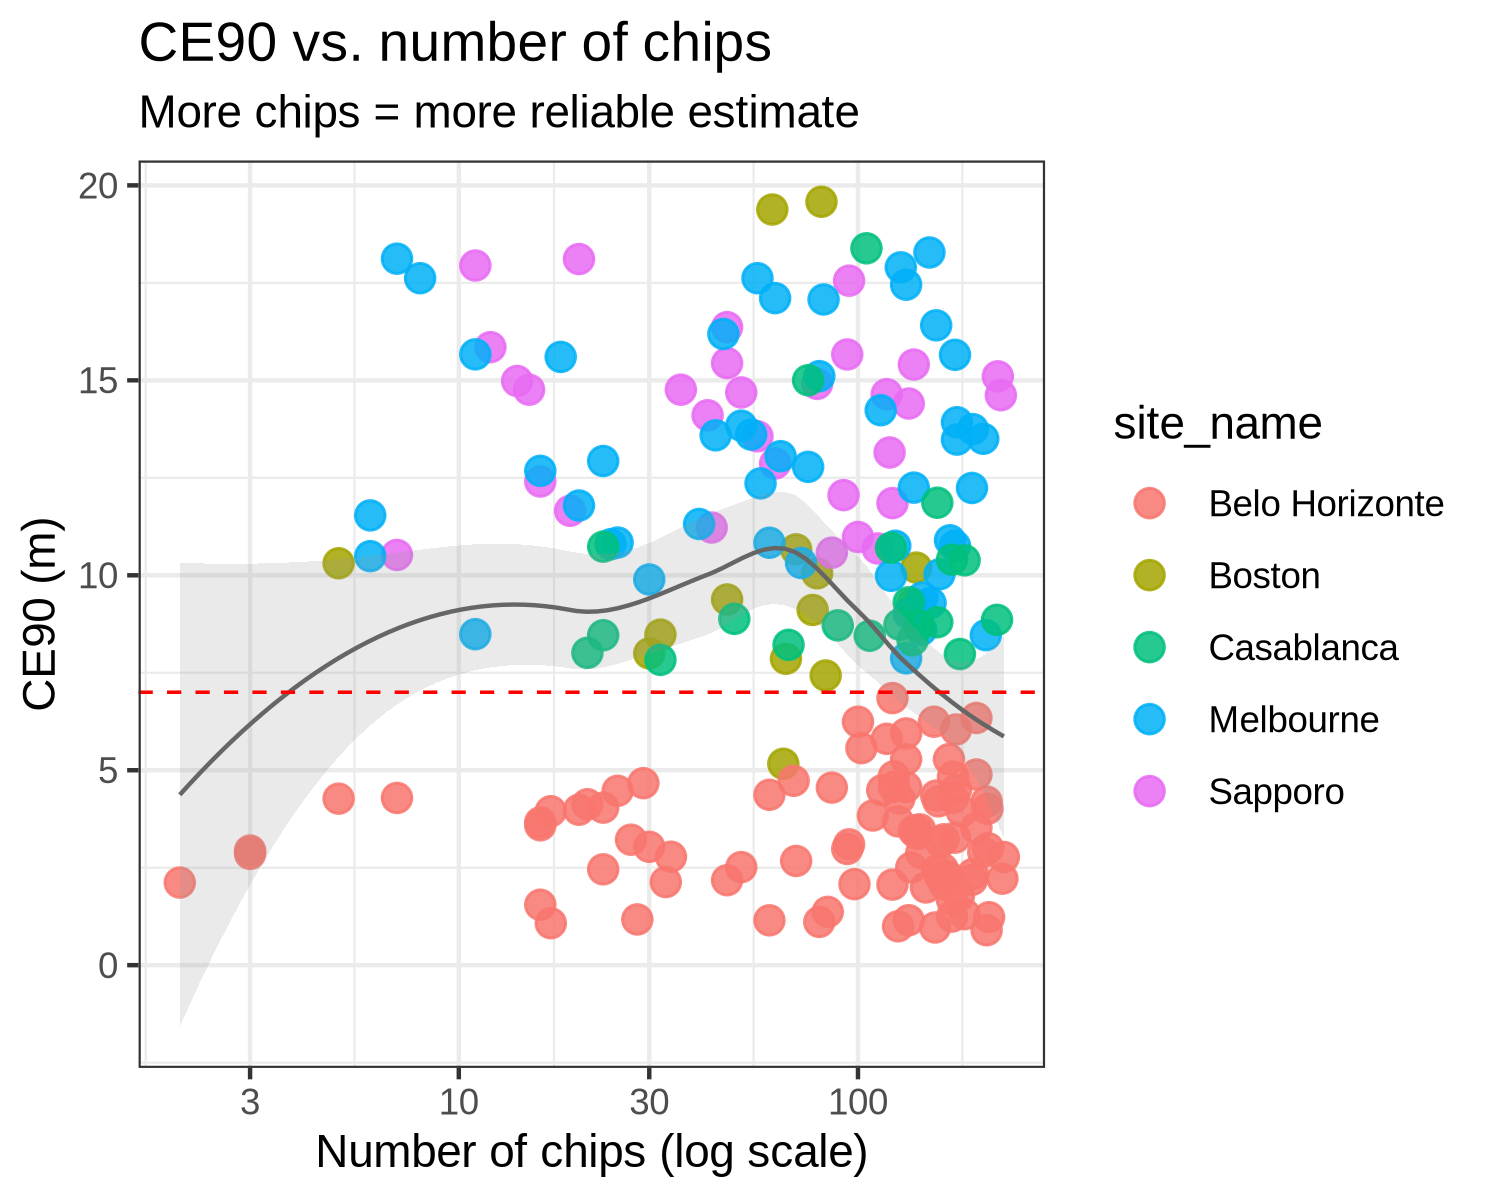

In [48]:
options(repr.plot.width = 5, repr.plot.height = 4, repr.plot.res = 300)

p3 <- ggplot(df_apa, aes(x = n_chips, y = ce90_m, color = site_name)) +
  geom_point(size = 3, alpha = 0.85) +
  geom_smooth(aes(group = 1), method = 'loess', se = TRUE, 
              color = 'grey40', size = 0.5, alpha = 0.2) +
  geom_hline(yintercept = CE90_THRESHOLD, color = 'red',
             linetype = 'dashed', linewidth = 0.4) +
  scale_x_log10() +
  labs(title = 'CE90 vs. number of chips',
       subtitle = 'More chips = more reliable estimate',
       x = 'Number of chips (log scale)', y = 'CE90 (m)') +
  theme_bw(base_size = 11)

p3

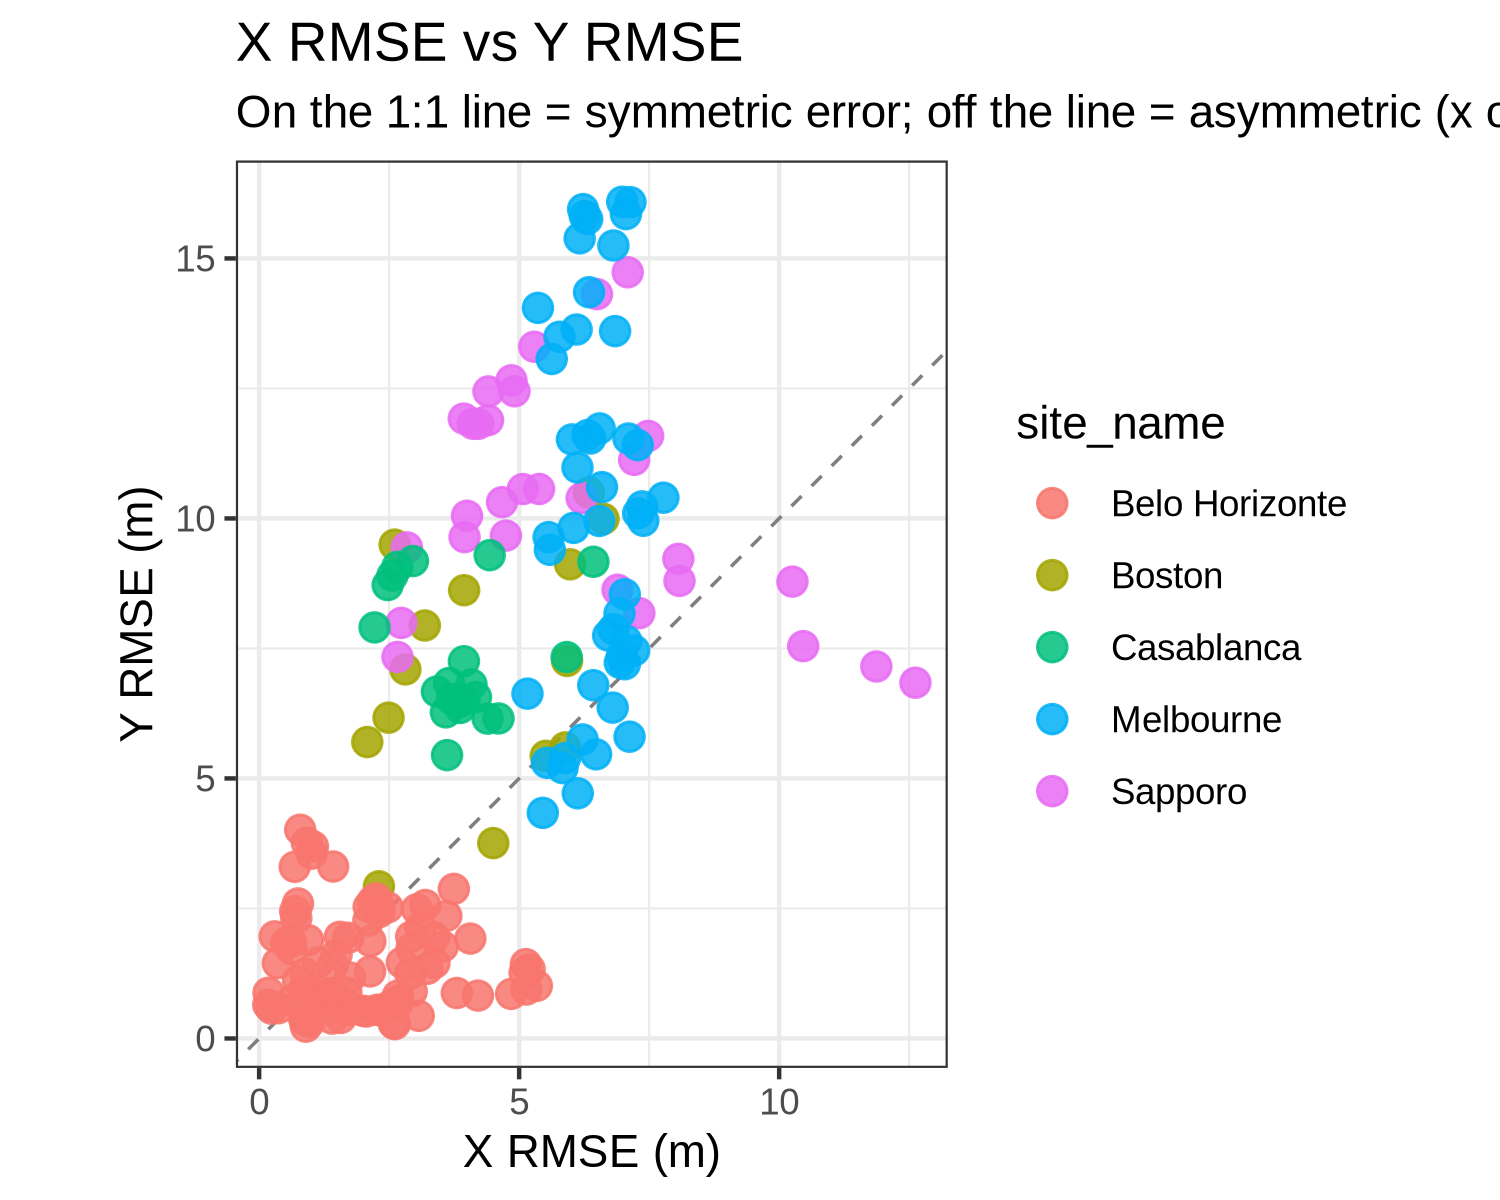

In [63]:
options(repr.plot.width = 5, repr.plot.height = 4, repr.plot.res = 300)

p4 <- ggplot(df_apa, aes(x = xrmse_m, y = yrmse_m, color = site_name)) +
  geom_abline(slope = 1, intercept = 0, linetype = 'dashed',
              color = 'grey50', linewidth = 0.4) +
  geom_point(size = 3, alpha = 0.85) +
  labs(title = 'X RMSE vs Y RMSE',
       subtitle = 'On the 1:1 line = symmetric error; off the line = asymmetric (x or y bias dominant)',
       x = 'X RMSE (m)', y = 'Y RMSE (m)') +
  theme_bw(base_size = 11) +
  coord_equal()

p4

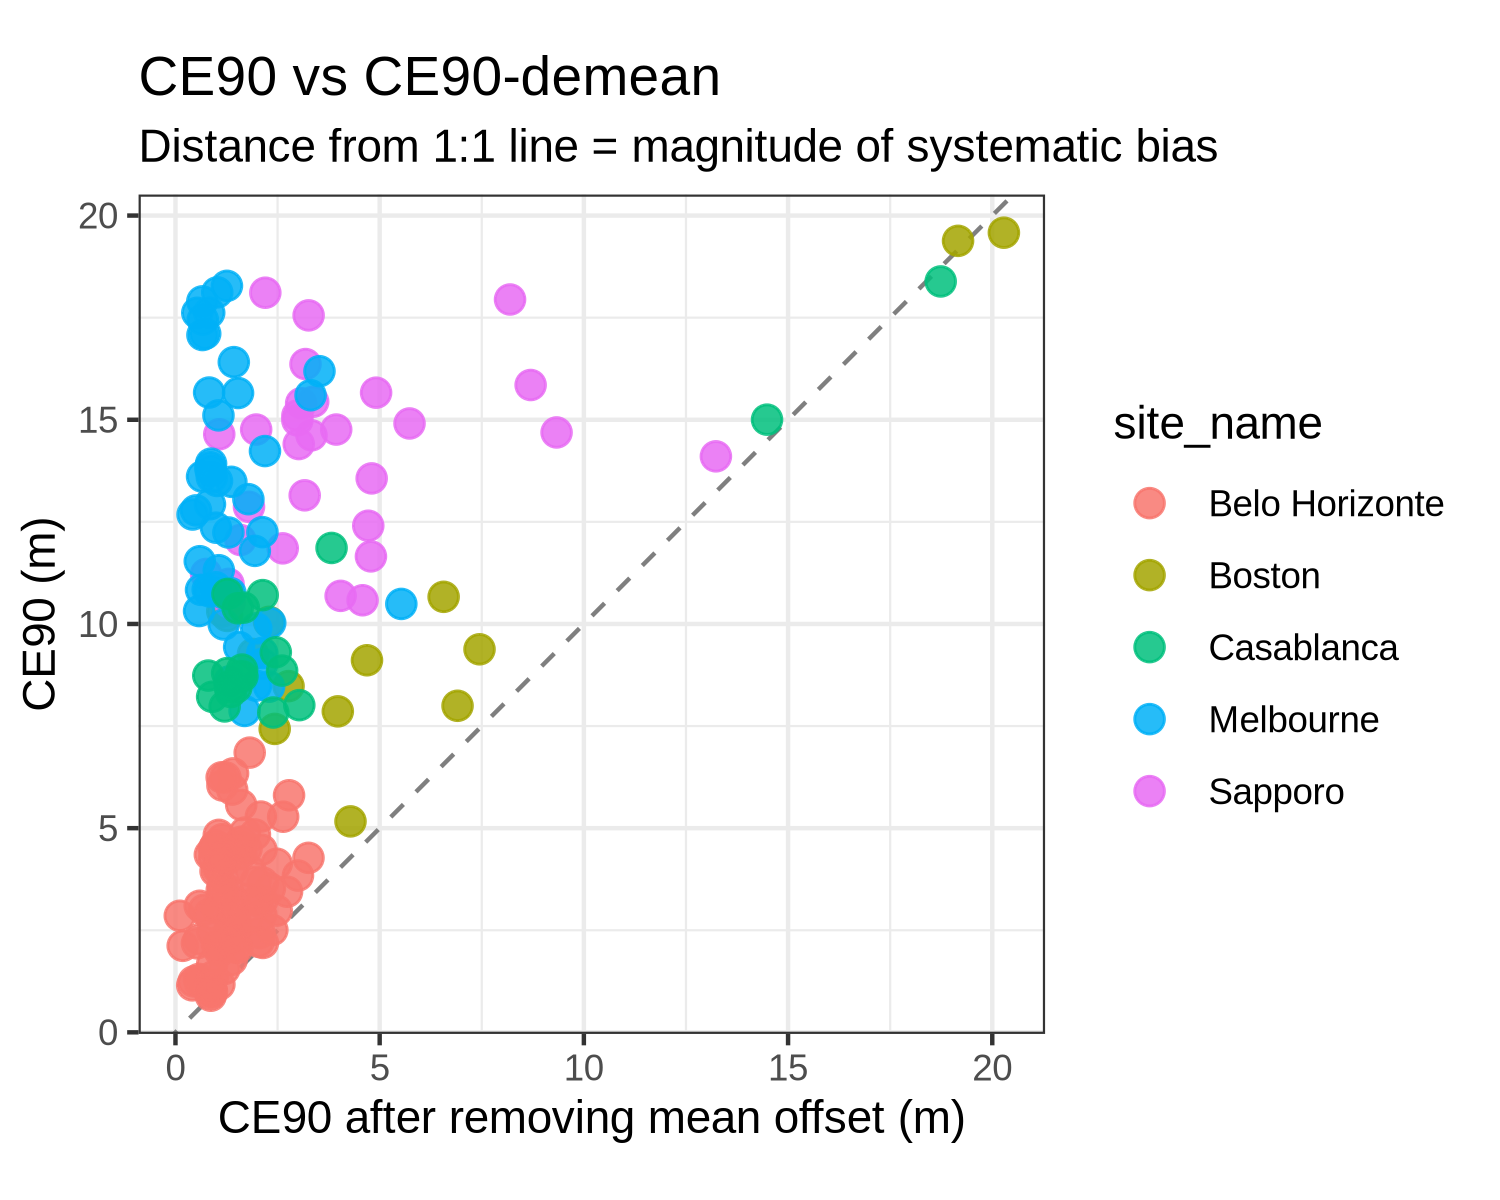

In [49]:
p5 <- ggplot(df_apa, aes(x = `ce90-demean_m`, y = ce90_m, color = site_name)) +
  geom_abline(slope = 1, intercept = 0, linetype = 'dashed',
              color = 'grey50') +
  geom_point(size = 3, alpha = 0.85) +
  labs(title = 'CE90 vs CE90-demean',
       subtitle = 'Distance from 1:1 line = magnitude of systematic bias',
       x = 'CE90 after removing mean offset (m)', y = 'CE90 (m)') +
  theme_bw(base_size = 11) +
  coord_equal()

p5

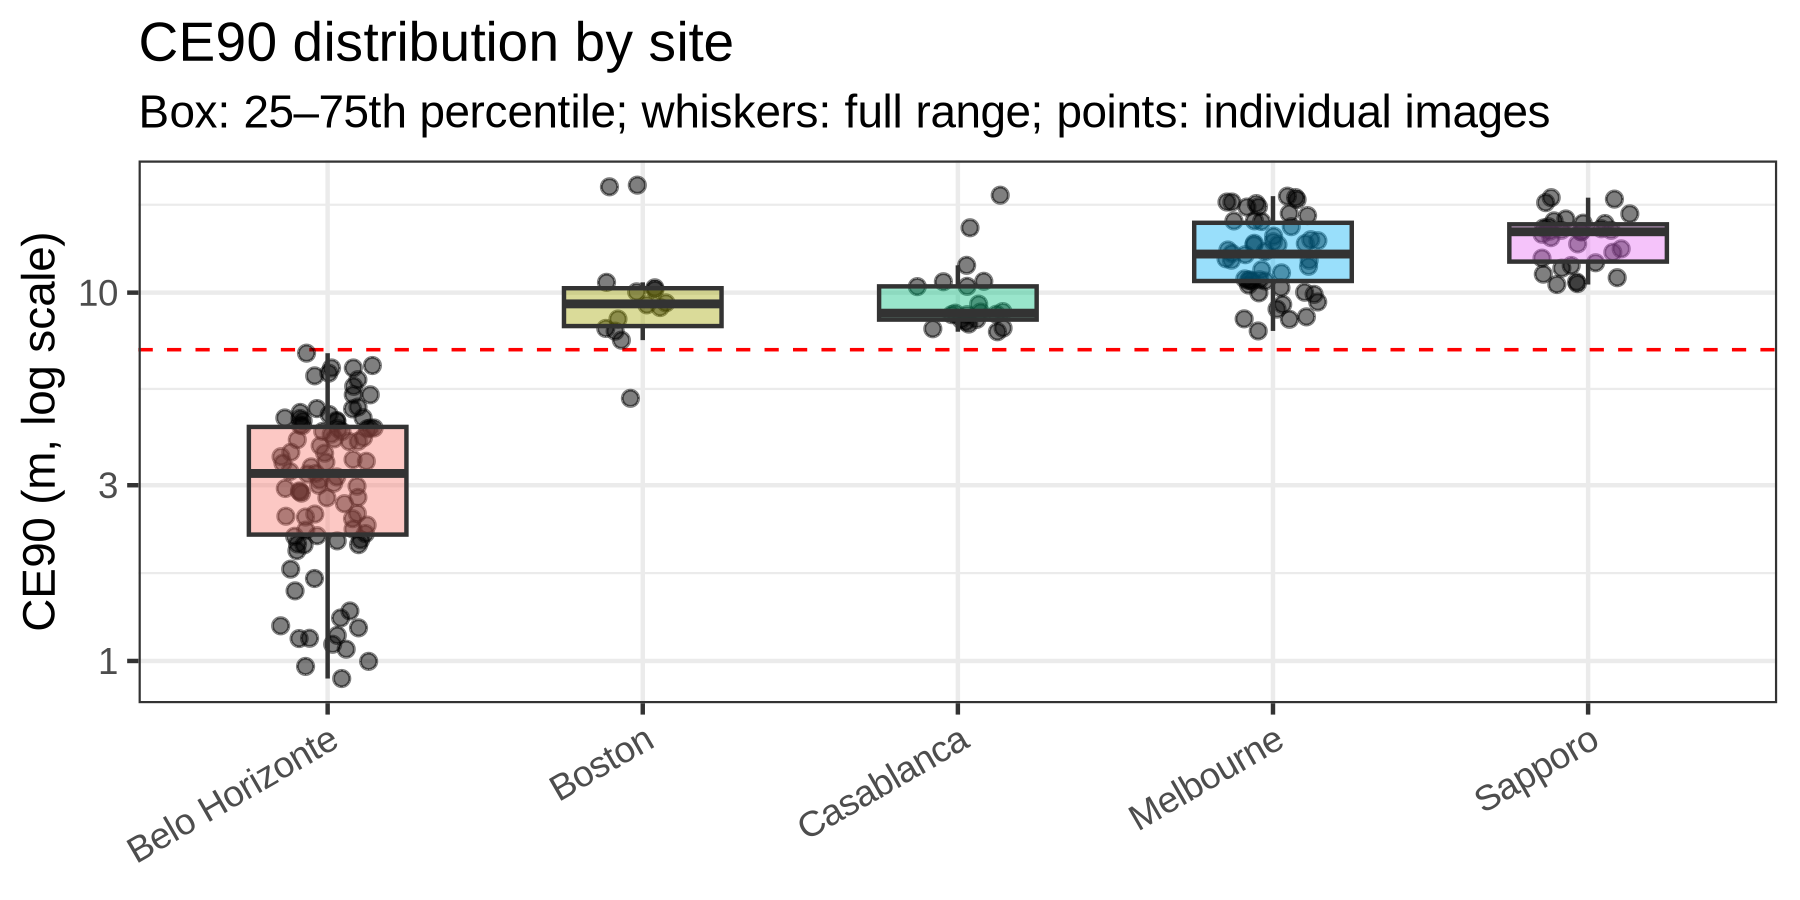

In [52]:
options(repr.plot.width = 6, repr.plot.height = 3, repr.plot.res = 300)

p6 <- df_apa %>%
  ggplot(aes(x = site_name, y = ce90_m, fill = site_name)) +
  geom_hline(yintercept = CE90_THRESHOLD, color = 'red',
             linetype = 'dashed', linewidth = 0.4) +
  geom_jitter(width = 0.15, alpha = 0.5, size = 1.5) +
  geom_boxplot(alpha = 0.4, outlier.shape = NA, width = 0.5) +
  scale_y_continuous(trans = 'log10') +
  labs(title = 'CE90 distribution by site',
       subtitle = 'Box: 25–75th percentile; whiskers: full range; points: individual images',
       x = NULL, y = 'CE90 (m, log scale)') +
  theme_bw(base_size = 11) +
  theme(axis.text.x = element_text(angle = 30, hjust = 1),
        legend.position = 'none')

p6

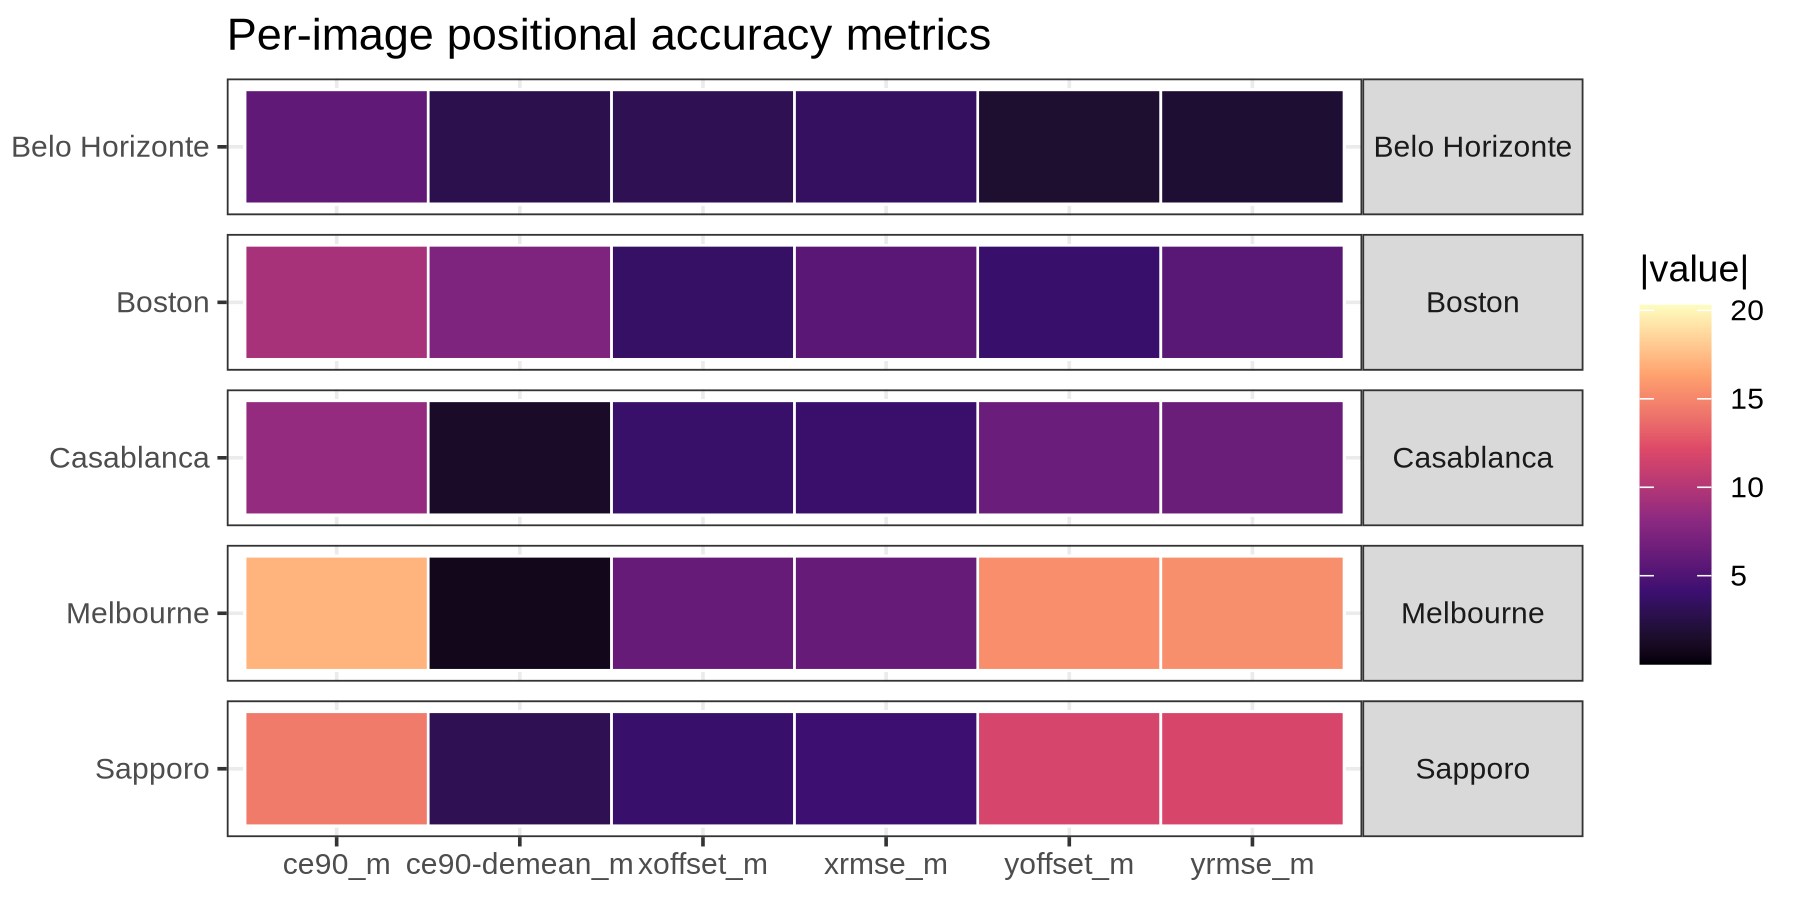

In [61]:
options(repr.plot.width = 6, repr.plot.height = 3, repr.plot.res = 300)

metrics_long <- df_apa %>%
  select(file_name, site_name,
         xoffset_m, yoffset_m, xrmse_m, yrmse_m, ce90_m, `ce90-demean_m`) %>%
  pivot_longer(-c(file_name, site_name),
               names_to = 'metric', values_to = 'value')

p7 <- ggplot(metrics_long, aes(x = metric, y = site_name, fill = abs(value))) +
  geom_tile(color = 'white', linewidth = 0.3) +
  #geom_text(aes(label = sprintf('%.1f', value)), size = 2.8, color = 'white') +
  scale_fill_viridis_c(option = 'magma', direction = 1, name = '|value|') +
  facet_grid(site_name ~ ., scales = 'free_y', space = 'free_y') +
  labs(title = 'Per-image positional accuracy metrics',
       x = NULL, y = NULL) +
  theme_bw(base_size = 9) +
  theme(strip.text.y = element_text(angle = 0))

p7

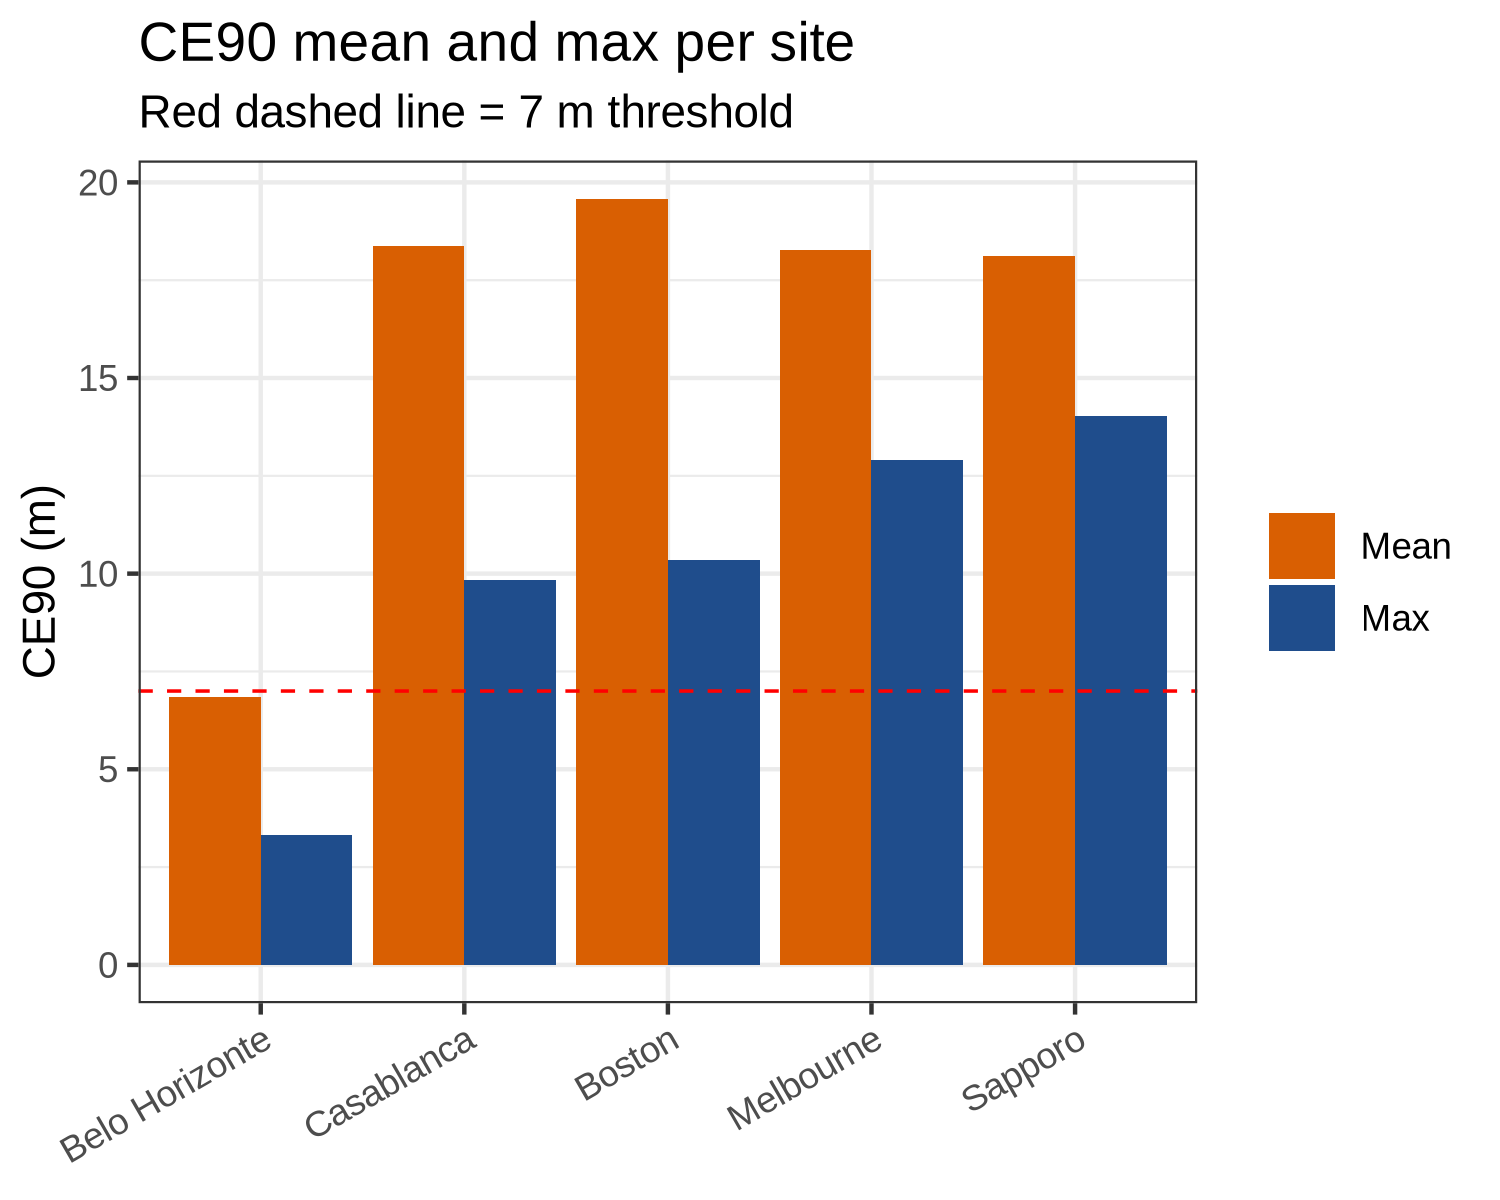

In [64]:
# Plot 8 (continued)
p8 <- df_apa %>%
  group_by(site_name) %>%
  summarise(
    n_images   = n(),
    ce90_mean  = mean(ce90_m),
    ce90_max   = max(ce90_m),
    .groups = 'drop'
  ) %>%
  pivot_longer(c(ce90_mean, ce90_max),
               names_to = 'stat', values_to = 'ce90') %>%
  ggplot(aes(x = reorder(site_name, ce90), y = ce90, fill = stat)) +
  geom_col(position = 'dodge') +
  geom_hline(yintercept = CE90_THRESHOLD, color = 'red',
             linetype = 'dashed', linewidth = 0.4) +
  scale_fill_manual(values = c(ce90_mean = '#1f4d8c', ce90_max = '#d95f02'),
                    labels = c('Mean', 'Max'),
                    name = NULL) +
  labs(title = 'CE90 mean and max per site',
       subtitle = sprintf('Red dashed line = %d m threshold', CE90_THRESHOLD),
       x = NULL, y = 'CE90 (m)') +
  theme_bw(base_size = 11) +
  theme(axis.text.x = element_text(angle = 30, hjust = 1))

p8

`height` was translated to `width`.


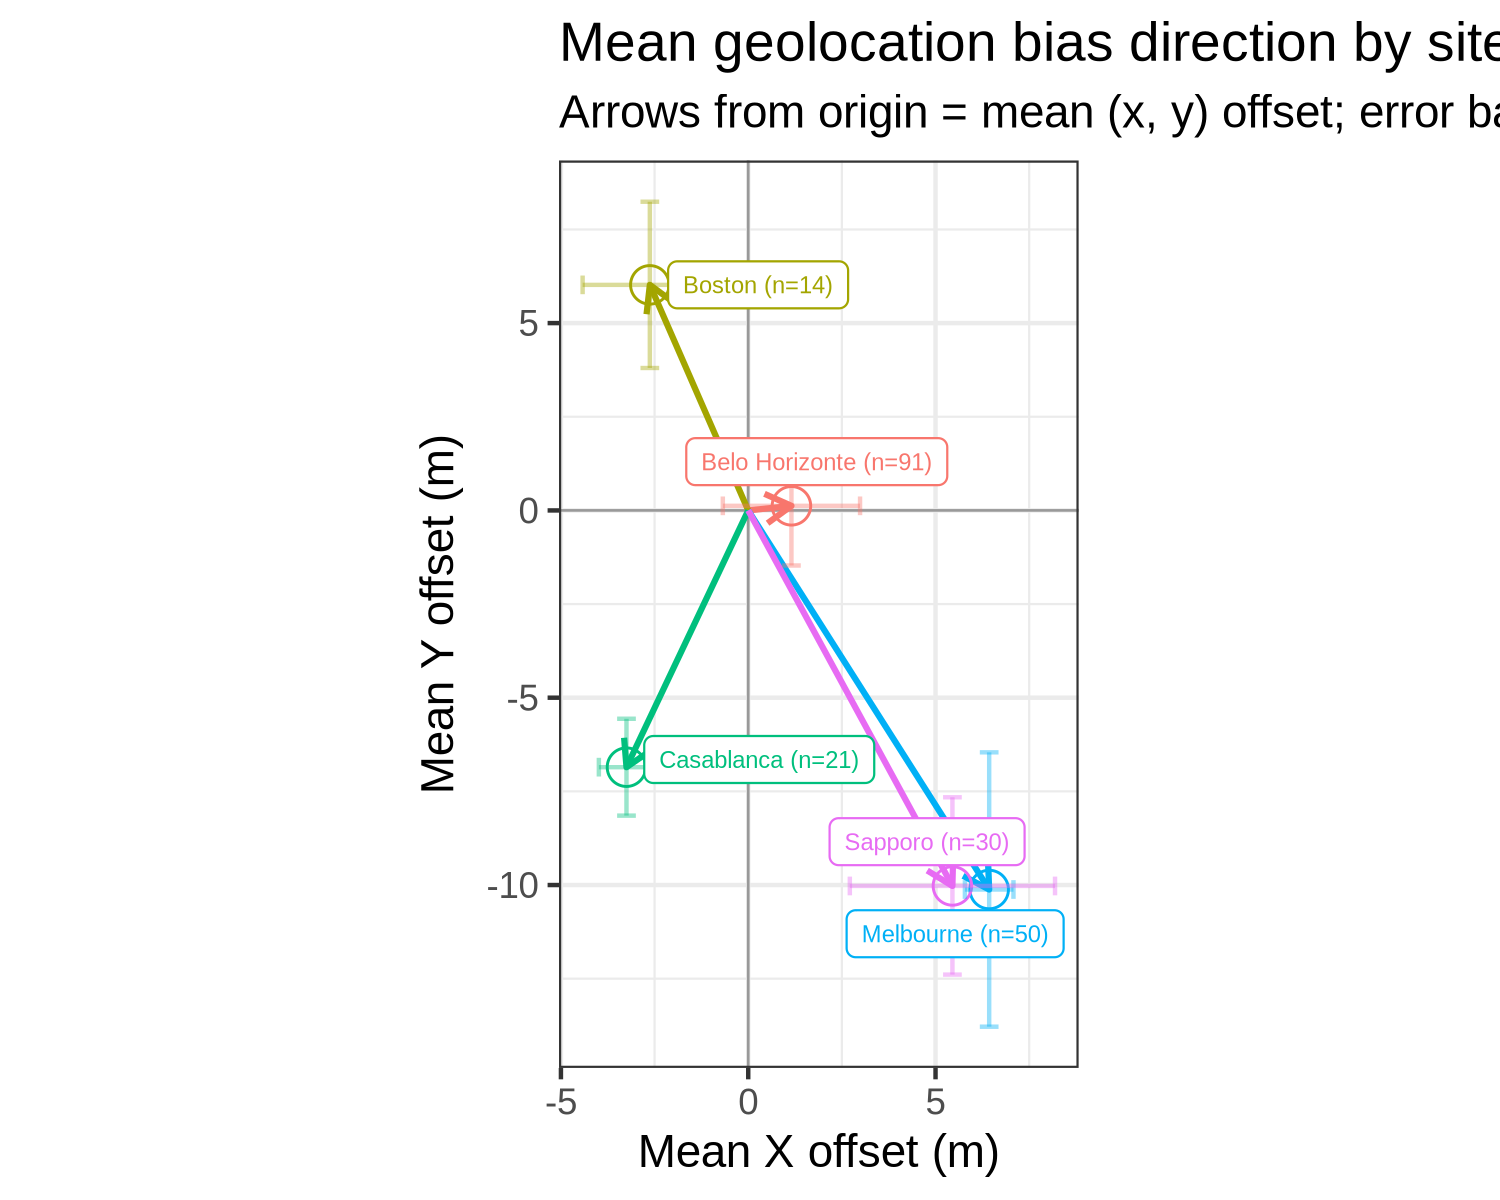

In [70]:
p9 <- df_apa %>%
  group_by(site_name) %>%
  summarise(
    mean_x = mean(xoffset_m),
    mean_y = mean(yoffset_m),
    sd_x   = sd(xoffset_m),
    sd_y   = sd(yoffset_m),
    n      = n(),
    .groups = 'drop'
  ) %>%
  ggplot(aes(x = mean_x, y = mean_y, color = site_name)) +
  geom_hline(yintercept = 0, color = 'grey60', linewidth = 0.3) +
  geom_vline(xintercept = 0, color = 'grey60', linewidth = 0.3) +
  geom_segment(aes(xend = 0, yend = 0),
               arrow = arrow(length = unit(0.25, 'cm'), ends = 'first'),
               linewidth = 0.7) +
  geom_point(size = 4, shape=1) +
  geom_errorbar(aes(ymin = mean_y - sd_y, ymax = mean_y + sd_y),
                width = 0.5, alpha = 0.4) +
  geom_errorbarh(aes(xmin = mean_x - sd_x, xmax = mean_x + sd_x),
                 height = 0.5, alpha = 0.4) +
  geom_label_repel(aes(label = paste0(site_name, ' (n=', n, ')')),
                  size = 2, point.padding = 0.5,
                  show.legend = FALSE) +
  labs(title = 'Mean geolocation bias direction by site',
       subtitle = 'Arrows from origin = mean (x, y) offset; error bars = ±1 SD',
       x = 'Mean X offset (m)', y = 'Mean Y offset (m)') +
  theme_bw(base_size = 11) +
  theme(legend.position = 'none') +
  coord_equal()

p9

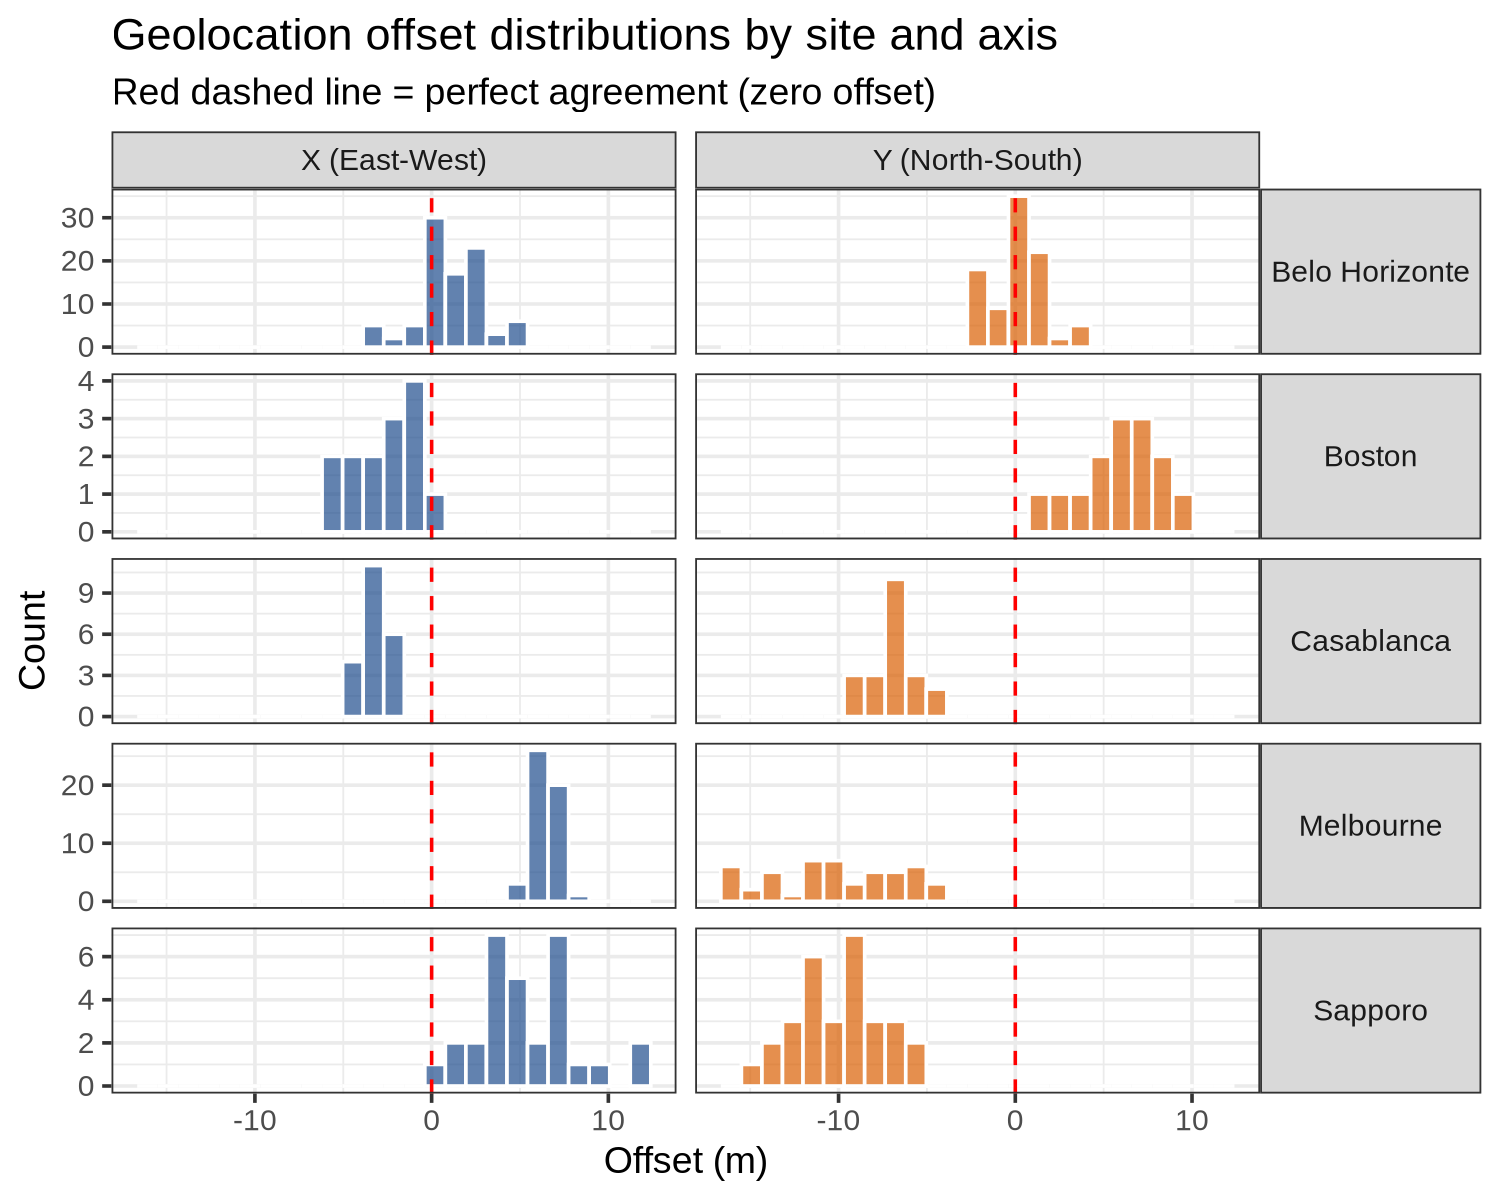

In [71]:
p10 <- df_apa %>%
  pivot_longer(c(xoffset_m, yoffset_m),
               names_to = 'axis', values_to = 'offset') %>%
  mutate(axis = recode(axis,
                       xoffset_m = 'X (East-West)',
                       yoffset_m = 'Y (North-South)')) %>%
  ggplot(aes(x = offset, fill = axis)) +
  geom_histogram(bins = 25, alpha = 0.7, position = 'identity', color = 'white') +
  geom_vline(xintercept = 0, color = 'red',
             linetype = 'dashed', linewidth = 0.4) +
  facet_grid(site_name ~ axis, scales = 'free_y') +
  scale_fill_manual(values = c('X (East-West)' = '#1f4d8c',
                               'Y (North-South)' = '#d95f02')) +
  labs(title = 'Geolocation offset distributions by site and axis',
       subtitle = 'Red dashed line = perfect agreement (zero offset)',
       x = 'Offset (m)', y = 'Count') +
  theme_bw(base_size = 9) +
  theme(legend.position = 'none',
        strip.text.y = element_text(angle = 0))

p10

In [76]:
# options(repr.plot.width = 10, repr.plot.height = 20, repr.plot.res = 300)

# library(patchwork)

# dashboard <- (p1 | p9) /
#              (p3 | p4) /
#              (p8 | p2)

# dashboard +
#   plot_annotation(
#     title = 'Absolute Positional Accuracy — Summary Dashboard',
#     subtitle = sprintf('Threshold: CE90 ≤ %d m', CE90_THRESHOLD),
#     theme = theme(plot.title = element_text(face = 'bold', size = 14))
#   )

## Absolute Calibration